In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
visa_df = pd.read_csv(r"C:\Users\vinay\Downloads\Visadataset (1).csv")

- variate: variables

- Bi variate: Two variable analysis

- Multi variate: More than two variable analysis

In [4]:
cat = visa_df.select_dtypes(include = object).columns
num = visa_df.select_dtypes(exclude = object).columns

In [5]:
# we have two columns one is continent column and another one is case_status
visa_df['continent'].value_counts()

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

In [6]:
con1 = visa_df['case_status'] == 'Certified'
con2 = visa_df['continent'] == 'Asia'
con = con1 & con2
len(visa_df[con])

11012

In [7]:
con1 = visa_df['case_status'] == 'Certified'
con2 = visa_df['continent'] == 'Asia'
con3 = visa_df['case_status'] == 'Denied'
certi_con = con1 & con2
deni_con = con2 & con3
len(visa_df[certi_con]), len(visa_df[deni_con]) 

(11012, 5849)

In [8]:
 visa_df['case_status'].value_counts()

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

In [9]:
# task 
# how many asia std got certified
# how many asian student got denied

In [10]:
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [11]:
con1 = visa_df['continent']=='Asia'
con2 = visa_df['case_status'] == 'Certified'
con = con1 & con2
len(visa_df[con])

11012

In [12]:
con3 = visa_df['continent']=='Asia'
con4 = visa_df['case_status'] == 'Denied'
con5 = con3 & con4
len(visa_df[con5])


5849

In [13]:
11012 + 5849

16861

In [14]:
visa_df['continent'].unique()

array(['Asia', 'Africa', 'North America', 'Europe', 'South America',
       'Oceania'], dtype=object)

In [15]:
conti = visa_df['continent'].unique()
certi_list = []
deni_list = []
for i in conti:
    con1 = visa_df['continent'] == i
    con2 = visa_df['case_status'] == 'Certified'
    con3 = visa_df['case_status'] == 'Denied'
    certi_con = con1 & con2
    deni_con = con1 & con3
    certi_list.append(len(visa_df[certi_con]))
    deni_list.append(len(visa_df[deni_con]))

certi_list
deni_list

[5849, 154, 1255, 775, 359, 70]

In [16]:
continent = visa_df['continent'].unique()
certified_list = []
for i in continent:
    con1 = visa_df['continent']== i
    con2 = visa_df['case_status'] == 'Certified'
    con = con1 & con2
    certified_list.append(len(visa_df[con]))

certified_list


[11012, 397, 2037, 2957, 493, 122]

In [17]:
continent = visa_df['continent'].unique()
denied_list = []
for i in continent:
    con1 = visa_df['continent']== i
    con2 = visa_df['case_status'] == 'Denied'
    con = con1 & con2
    denied_list.append(len(visa_df[con]))

denied_list

[5849, 154, 1255, 775, 359, 70]

In [18]:
continent = visa_df['continent'].unique()
denied_list = []
certified_list = []
for i in continent:
    con1 = visa_df['continent']== i
    con2 = visa_df['case_status'] == 'Certified'
    con3 = visa_df['case_status'] == 'Denied'
    certi_con = con1 & con2
    den_con = con1 & con3
    certified_list.append(len(visa_df[certi_con]))
    denied_list.append(len(visa_df[den_con]))
    


pd.DataFrame(zip(certified_list, denied_list),
            index = continent,
            columns = ['Certified', 'Denied'])

,Certified,Denied
Asia,11012,5849
Africa,397,154
North America,2037,1255
Europe,2957,775
South America,493,359
Oceania,122,70


In [19]:
con = visa_df['case_status'] == 'Certified'
con

0        False
1         True
2        False
3        False
4         True
         ...  
25475     True
25476     True
25477     True
25478     True
25479     True
Name: case_status, Length: 25480, dtype: bool

In [20]:
con = visa_df['case_status'] == 'Certified'
data = visa_df[con].groupby('continent').size() # used for 
data

continent
Africa             397
Asia             11012
Europe            2957
North America     2037
Oceania            122
South America      493
dtype: int64

In [21]:
col1 = visa_df['continent']
col2 = visa_df['case_status']
r1 = pd.crosstab(col1, col2)

In [22]:
col1 = visa_df['continent']
col2 = visa_df['case_status']
r2 = pd.crosstab(col2, col1)
r2

continent,Africa,Asia,Europe,North America,Oceania,South America
case_status,,,,,,
Certified,397,11012,2957,2037,122,493
Denied,154,5849,775,1255,70,359


<Axes: xlabel='continent'>

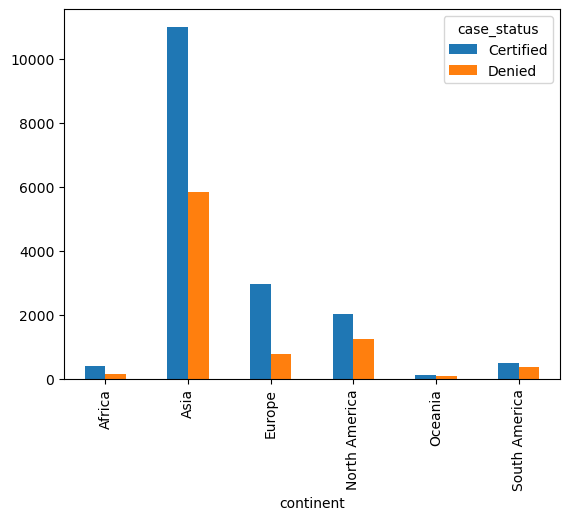

In [23]:
r1.plot(kind = 'bar')

<Axes: xlabel='case_status'>

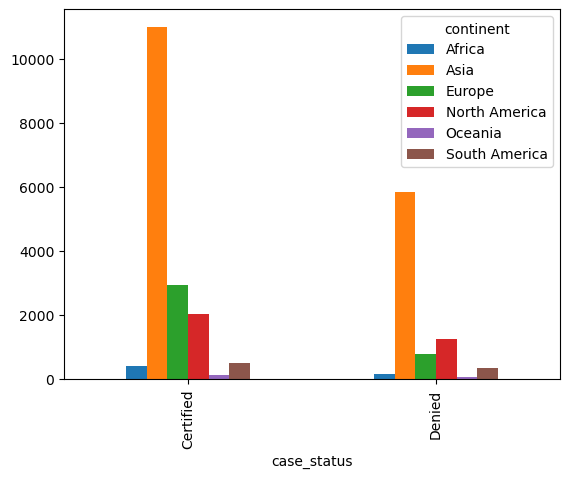

In [24]:
r2.plot(kind = 'bar')

<Axes: xlabel='case_status'>

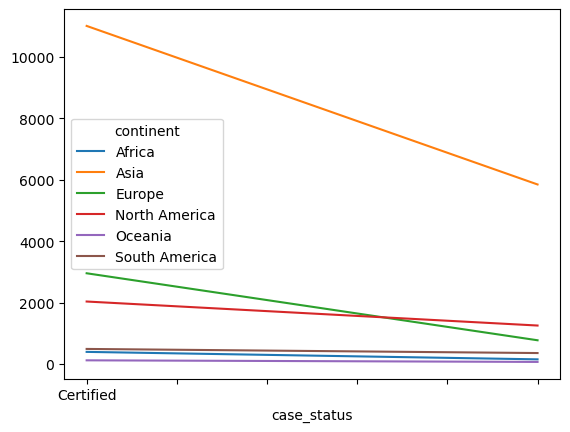

In [25]:
r2.plot(kind = 'line')

<Axes: ylabel='Frequency'>

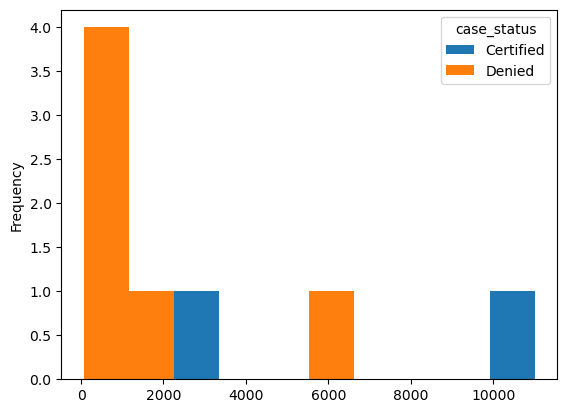

In [26]:
r1.plot(kind = 'hist')

array([<Axes: ylabel='Certified'>, <Axes: ylabel='Denied'>], dtype=object)

<Figure size 1500x1000 with 0 Axes>

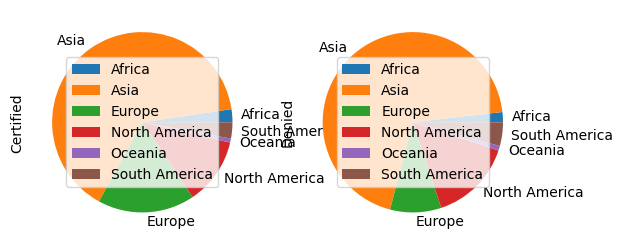

In [27]:
plt.figure(figsize=(15,10))
r1.plot(kind = 'pie', subplots = True)

con
edu of emp
case status

there are 11K aplicants certified from asia now i want to know edu wise q
11K based on eduactio
col1
col2
sel 3col3

In [29]:
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [30]:
col1 = visa_df['continent']
col2 = visa_df['case_status']
col3 = visa_df['education_of_employee']
cols = [col2,col3]

df = pd.crosstab(col1,cols)
df

case_status            Certified                                    Denied  \
education_of_employee Bachelor's Doctorate High School Master's Bachelor's   
continent                                                                    
Africa                        81        43          23      250         62   
Asia                        4407       780         676     5149       2761   
Europe                      1040       788         162      967        259   
North America                641       207         210      979        584   
Oceania                       38        19          19       46         28   
South America                160        75          74      184        173   

case_status                                           
education_of_employee Doctorate High School Master's  
continent                                             
Africa                       11          43       38  
Asia                        143        1614     1331  
Europe                       58         328      130  
North America                51         191      429  
Oceania                       3          17       22  
South America                14          63      109

In [31]:
col1 = visa_df['continent']
col2 = visa_df['case_status']
col3 = visa_df['education_of_employee']
cols = [col3,col2]

df = pd.crosstab(col1,cols)
df

education_of_employee Bachelor's        Doctorate        High School         \
case_status            Certified Denied Certified Denied   Certified Denied   
continent                                                                     
Africa                        81     62        43     11          23     43   
Asia                        4407   2761       780    143         676   1614   
Europe                      1040    259       788     58         162    328   
North America                641    584       207     51         210    191   
Oceania                       38     28        19      3          19     17   
South America                160    173        75     14          74     63   

education_of_employee  Master's         
case_status           Certified Denied  
continent                               
Africa                      250     38  
Asia                       5149   1331  
Europe                      967    130  
North America               979    429  
Oceania                      46     22  
South America               184    109

In [32]:
col1 = visa_df['continent']
col2 = visa_df['case_status']
col3 = visa_df['education_of_employee']
cols = [col1,col2]

df = pd.crosstab(col3,cols)
df

continent                Africa             Asia           Europe         \
case_status           Certified Denied Certified Denied Certified Denied   
education_of_employee                                                      
Bachelor's                   81     62      4407   2761      1040    259   
Doctorate                    43     11       780    143       788     58   
High School                  23     43       676   1614       162    328   
Master's                    250     38      5149   1331       967    130   

continent             North America          Oceania        South America  \
case_status               Certified Denied Certified Denied     Certified   
education_of_employee                                                       
Bachelor's                      641    584        38     28           160   
Doctorate                       207     51        19      3            75   
High School                     210    191        19     17            74   
Master's                        979    429        46     22           184   

continent                     
case_status           Denied  
education_of_employee         
Bachelor's               173  
Doctorate                 14  
High School               63  
Master's                 109

# **Numerical-Numerical**

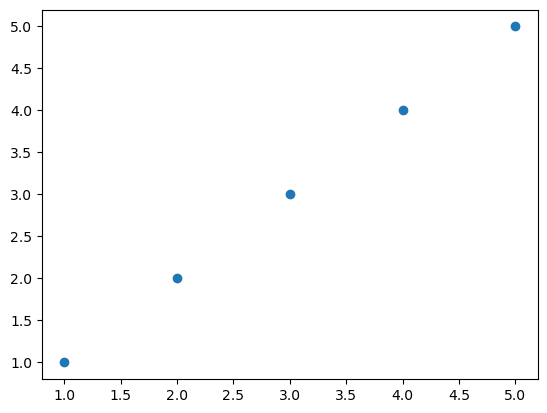

In [34]:
x = [1,2,3,4,5] 
y = [1,2,3,4,5]
plt.scatter(x, y)

plt.show()

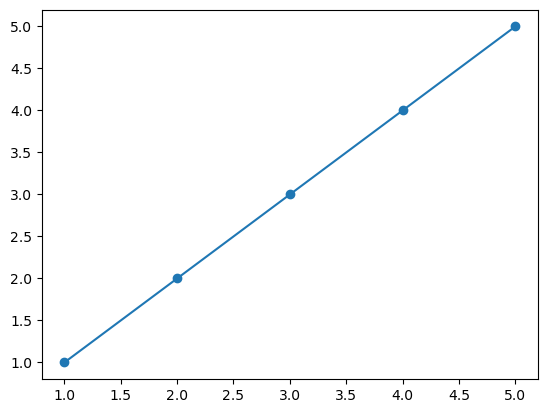

In [35]:
x = [1,2,3,4,5] 
y = [1,2,3,4,5]
plt.scatter(x, y)
plt.plot(x,y)
plt.show()

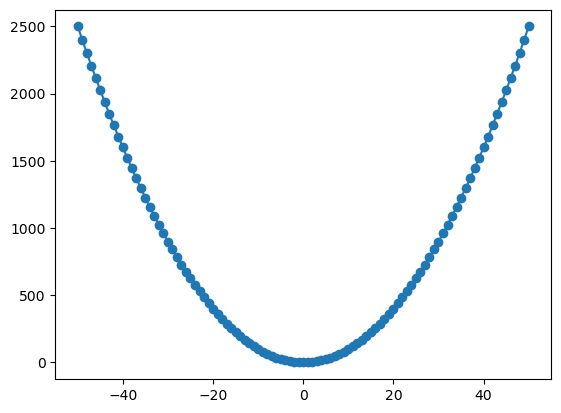

In [36]:
x = [i for i in range(-50,51)]
y = [i*i for i in x]
plt.scatter(x, y)
plt.plot(x,y)
plt.show()

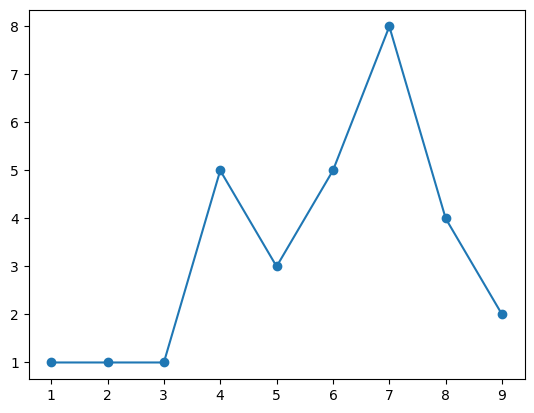

In [37]:
x = list(range(1,10))
y = [1,1,1,5,3,5,8,4,2]
plt.scatter(x, y)
plt.plot(x,y)
plt.show()

In [38]:
num

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

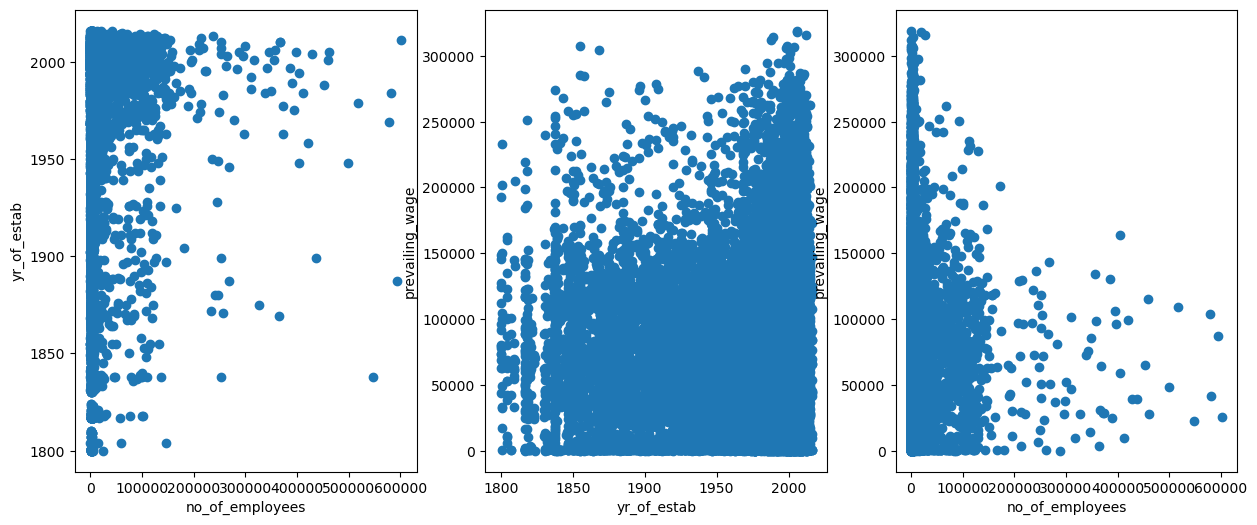

In [39]:
col1 = visa_df['no_of_employees']
col2 = visa_df['yr_of_estab']
col3 = visa_df['prevailing_wage']
plt.figure(figsize=(15,6))
plt.subplot(1,3,1).scatter(col1, col2)
plt.xlabel('no_of_employees')
plt.ylabel('yr_of_estab')
plt.subplot(1,3,2).scatter(col2, col3)
plt.xlabel('yr_of_estab')
plt.ylabel('prevailing_wage')
plt.subplot(1,3,3).scatter(col1, col3)
plt.xlabel('no_of_employees')
plt.ylabel('prevailing_wage')

plt.show()

# Pearson's Corelation coeficent

In [41]:
visa_df.corr(numeric_only=True) # It gives output of Covarience Matrix


,no_of_employees,yr_of_estab,prevailing_wage
no_of_employees,1.000000,-0.017770,-0.009523
yr_of_estab,-0.017770,1.000000,0.012342
prevailing_wage,-0.009523,0.012342,1.000000


# Heat Map

<Axes: >

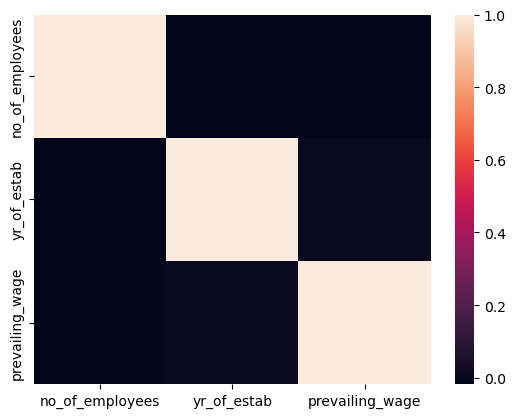

In [43]:
import seaborn as sns
corr = visa_df.corr(numeric_only=True)
sns.heatmap(corr)

<Axes: >

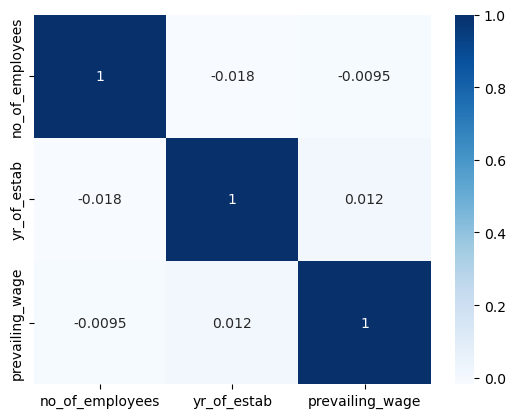

In [44]:
import seaborn as sns
corr = visa_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, 
           cmap = 'Blues')

In [45]:
wine_df = pd.read_csv(r"C:\Users\vinay\Eda 2\winequality_red.csv")

In [46]:
num = wine_df.select_dtypes(exclude = object).columns

In [47]:
num

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

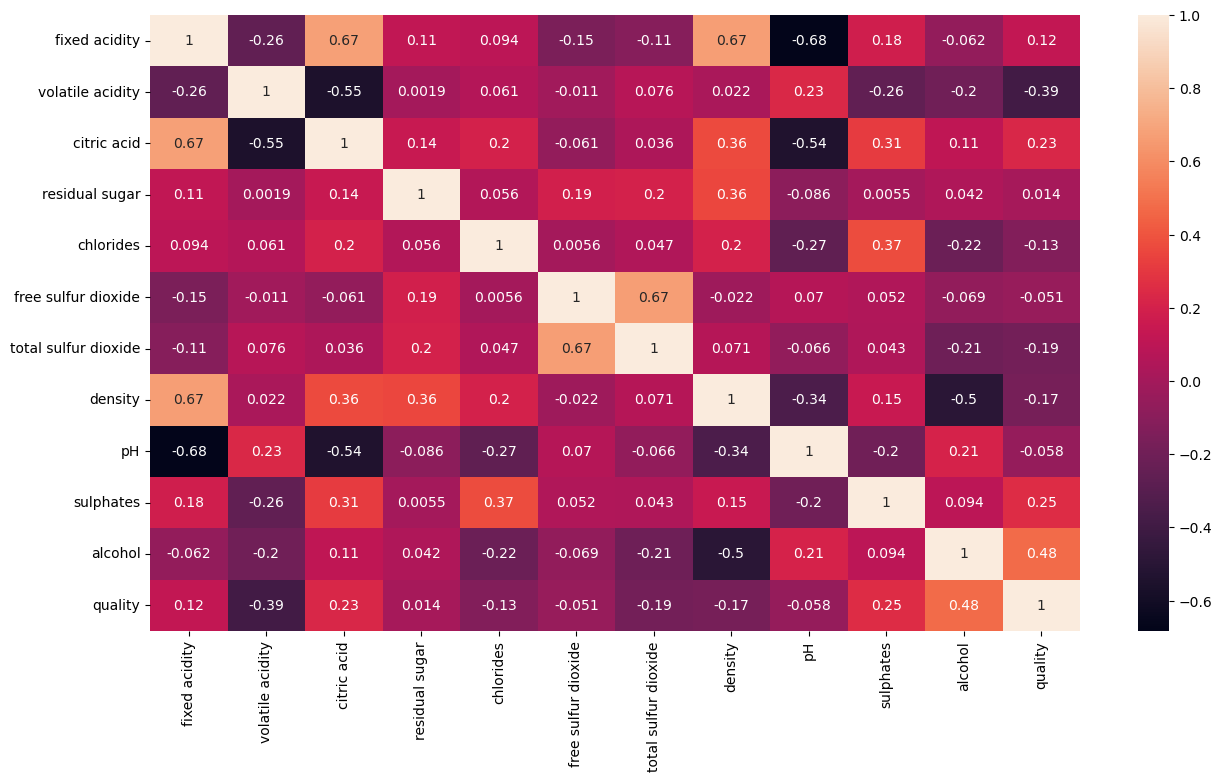

In [48]:
plt.figure(figsize=(15,8))
corr1 = wine_df.corr(numeric_only=True)
sns.heatmap(corr1, annot=True)
plt.show()

In [49]:
wine_df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


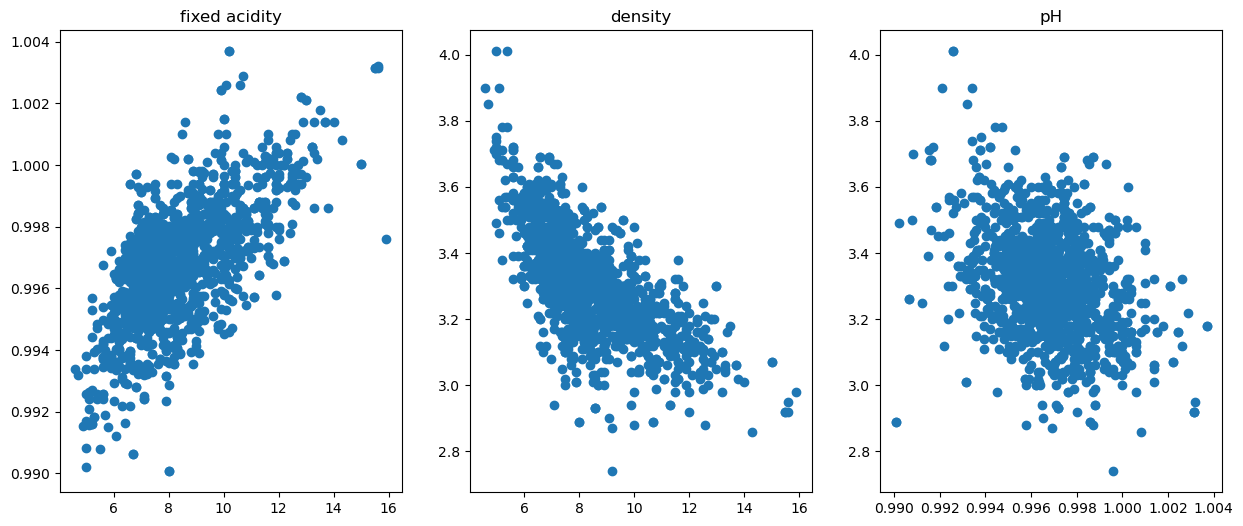

In [50]:
col1 = wine_df['fixed acidity']
col2 = wine_df['density']
col3 = wine_df['pH']
plt.figure(figsize=(15,6))
plt.subplot(1,3,1).scatter(col1, col2)
plt.xlabel('')
plt.title('fixed acidity')
plt.subplot(1,3,2).scatter(col1, col3)
plt.title('density')
plt.subplot(1,3,3).scatter(col2, col3)
plt.title('pH')
plt.show()

- generally we need good corelation input and output column

- we dont need a relation between input columns

In [52]:
corr1

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


In [53]:
corr1.iloc[:,-1] # its a series so we need to convert it into dataframe

fixed acidity           0.124052
volatile acidity       -0.390558
citric acid             0.226373
residual sugar          0.013732
chlorides              -0.128907
free sulfur dioxide    -0.050656
total sulfur dioxide   -0.185100
density                -0.174919
pH                     -0.057731
sulphates               0.251397
alcohol                 0.476166
quality                 1.000000
Name: quality, dtype: float64

In [54]:
df = pd.DataFrame(corr1.iloc[:,-1]).sort_values(by='quality', ascending = False)
df # we are sorting the values to get the corelation of the quality column that is output column with input columns

,quality
quality,1.000000
alcohol,0.476166
sulphates,0.251397
citric acid,0.226373
fixed acidity,0.124052
residual sugar,0.013732
free sulfur dioxide,-0.050656
pH,-0.057731
chlorides,-0.128907
density,-0.174919


In [55]:
corr1.sort_values(by = 'quality', ascending = False) # second method for sorting

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
quality,0.124052,-0.390558,0.226373,0.013732,-0.128907,-0.050656,-0.185100,-0.174919,-0.057731,0.251397,0.476166,1.000000
alcohol,-0.061668,-0.202288,0.109903,0.042075,-0.221141,-0.069408,-0.205654,-0.496180,0.205633,0.093595,1.000000,0.476166
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
